In [67]:
import pandas as pd

#### Rental and Income Data Integration (2011 - 2023)

In [68]:
# Load files
rental = pd.read_excel("Rental_Data.xlsx")
income = pd.read_excel("Income_Data.xlsx")

# Merge on City and Year
merged = rental.merge(income, on=["City", "Year"], how="left")

# Save merged file
merged.to_excel("Rental_Income_Integration.xlsx", index=False)

print("Merged rows:", len(merged))

Merged rows: 485


In [69]:
cleaned = pd.read_excel("Rental_Income_Integration.xlsx")

print(cleaned.tail())

          City                        Zone  Year Bedroom_Type  Vacancy_Rate  \
480  Saskatoon              Zone 5 - North  2023    2 Bedroom           0.7   
481  Saskatoon          Zone 6 - Southwest  2023    2 Bedroom           4.9   
482  Saskatoon               Zone 7 - West  2023    2 Bedroom           2.0   
483  Saskatoon  Saskatoon City (Zones 1-7)  2023    2 Bedroom           1.5   
484  Saskatoon               Saskatoon CMA  2023    2 Bedroom           1.5   

     Avg_Rent  No_Of_Apts  Median_Before_Tax_Income_Of_Households  \
480      1293         845                                   83219   
481      1013         796                                   83219   
482      1410        1763                                   83219   
483      1362        9319                                   83219   
484      1360        9420                                   83219   

     Median_After_Tax_Income_Of_Households  Median_After_Tax_Income_1Person  \
480                            

In [70]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person
count,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000
mean,2017.004124,4.906186,1017.581443,1965.026804,79718.057732,69264.967010,37524.835052,86676.232990
std,3.741103,3.692387,146.684924,2283.376333,4452.145785,4073.440299,2272.170930,5126.827171
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000
25%,2014.000000,2.000000,904.000000,481.000000,76457.000000,66074.000000,35666.000000,82696.000000
50%,2017.000000,4.300000,996.000000,1024.000000,78112.000000,68036.000000,36917.000000,85115.000000
75%,2020.000000,6.800000,1117.000000,1931.000000,83530.000000,73072.000000,38665.000000,91217.000000
max,2023.000000,19.400000,1454.000000,9420.000000,88389.000000,77005.000000,42277.000000,96634.000000


#### Creating new column : "Annual_Rent" - By multiplicating "Avg_Rent" column with 12

In [71]:
cleaned["Annual_Rent"] = cleaned["Avg_Rent"] * 12

cleaned.tail()

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent
480,Saskatoon,Zone 5 - North,2023,2 Bedroom,0.7,1293,845,83219,72750,37997,90816,15516
481,Saskatoon,Zone 6 - Southwest,2023,2 Bedroom,4.9,1013,796,83219,72750,37997,90816,12156
482,Saskatoon,Zone 7 - West,2023,2 Bedroom,2.0,1410,1763,83219,72750,37997,90816,16920
483,Saskatoon,Saskatoon City (Zones 1-7),2023,2 Bedroom,1.5,1362,9319,83219,72750,37997,90816,16344
484,Saskatoon,Saskatoon CMA,2023,2 Bedroom,1.5,1360,9420,83219,72750,37997,90816,16320


In [72]:
print("Minimum Monthly Rent:", cleaned["Avg_Rent"].min())
print("Maximum Monthly Rent:", cleaned["Avg_Rent"].max())

print()

print("Minimum Before tax Income of Households:", cleaned["Median_Before_Tax_Income_Of_Households"].min())
print("Maximum Before tax Income of Households:", cleaned["Median_Before_Tax_Income_Of_Households"].max())

print()

print("Minimum after tax Income of Households:", cleaned["Median_After_Tax_Income_Of_Households"].min())
print("Maximum after tax Income of Households:", cleaned["Median_After_Tax_Income_Of_Households"].max())

print()

print("Minimum after tax Income of 1Person:", cleaned["Median_After_Tax_Income_1Person"].min())
print("Maximum after tax Income of 1Person:", cleaned["Median_After_Tax_Income_1Person"].max())

print()

print("Minimum after tax Income of 2Plus_Person:", cleaned["Median_After_Tax_Income_2Plus_Person"].min())
print("Maximum after tax Income of 2Plus_Person:", cleaned["Median_After_Tax_Income_2Plus_Person"].max())


Minimum Monthly Rent: 658
Maximum Monthly Rent: 1454

Minimum Before tax Income of Households: 72468
Maximum Before tax Income of Households: 88389

Minimum after tax Income of Households: 63120
Maximum after tax Income of Households: 77005

Minimum after tax Income of 1Person: 33883
Maximum after tax Income of 1Person: 42277

Minimum after tax Income of 2Plus_Person: 78965
Maximum after tax Income of 2Plus_Person: 96634


In [73]:
print("Shape:", cleaned.shape)

Shape: (485, 12)


In [74]:
cleaned[cleaned["Zone"].str.extract(r"(\d+)")[0].isnull()]["Zone"].unique()

array(['Regina CMA', 'Saskatoon CMA'], dtype=object)

In [75]:
# Extract numeric zone (works for all formats)
cleaned["Zone_Num"] = (
    cleaned["Zone"]
    .str.extract(r"(\d+)")
    .astype(float)
)

# Drop invalid rows (if any)
cleaned = cleaned.dropna(subset=["Zone_Num"])

# Convert to integer
cleaned["Zone_Num"] = cleaned["Zone_Num"].astype(int)

In [76]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,12212.618938,3.796767
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,1784.710586,2.245425
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,7896.000000,1.000000
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,10836.000000,2.000000
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,11952.000000,4.000000
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,13416.000000,6.000000
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,17448.000000,8.000000


## Feature Engineering Starts

#### "Affordability_Ratio" = Dividing "Annual_Rent" by "Median_After_Tax_Income_Of_Households"

In [77]:
cleaned["Affordability_Ratio"] = (
    cleaned["Annual_Rent"] /
    cleaned["Median_After_Tax_Income_Of_Households"]
)

In [78]:
cleaned.tail(10)

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,Affordability_Ratio
473,Saskatoon,Zone 7 - West,2023,1 Bedroom,3.0,1166,546,83219,72750,37997,90816,13992,7,0.192330
474,Saskatoon,Saskatoon City (Zones 1-7),2023,1 Bedroom,2.7,1090,5929,83219,72750,37997,90816,13080,1,0.179794
476,Saskatoon,Zone 1 - Central,2023,2 Bedroom,2.5,1380,800,83219,72750,37997,90816,16560,1,0.227629
477,Saskatoon,Zone 2 - South,2023,2 Bedroom,1.1,1403,2046,83219,72750,37997,90816,16836,2,0.231423
478,Saskatoon,Zone 3 - Southeast,2023,2 Bedroom,0.8,1374,1570,83219,72750,37997,90816,16488,3,0.226639
479,Saskatoon,Zone 4 - Northeast,2023,2 Bedroom,0.4,1454,1499,83219,72750,37997,90816,17448,4,0.239835
480,Saskatoon,Zone 5 - North,2023,2 Bedroom,0.7,1293,845,83219,72750,37997,90816,15516,5,0.213278
481,Saskatoon,Zone 6 - Southwest,2023,2 Bedroom,4.9,1013,796,83219,72750,37997,90816,12156,6,0.167093
482,Saskatoon,Zone 7 - West,2023,2 Bedroom,2.0,1410,1763,83219,72750,37997,90816,16920,7,0.232577
483,Saskatoon,Saskatoon City (Zones 1-7),2023,2 Bedroom,1.5,1362,9319,83219,72750,37997,90816,16344,1,0.224660


In [79]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,Affordability_Ratio
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,12212.618938,3.796767,0.176240
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,1784.710586,2.245425,0.022932
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,7896.000000,1.000000,0.122571
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,10836.000000,2.000000,0.156817
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,11952.000000,4.000000,0.174420
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,13416.000000,6.000000,0.192780
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,17448.000000,8.000000,0.239835


#### "SPV" = Dividing "Annual_Rent" by "Median_After_Tax_Income_Of_1Person"

In [80]:
cleaned["SPV"] = (
    cleaned["Annual_Rent"] /
    cleaned["Median_After_Tax_Income_1Person"]
)

In [81]:
cleaned.tail()

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,Affordability_Ratio,SPV
479,Saskatoon,Zone 4 - Northeast,2023,2 Bedroom,0.4,1454,1499,83219,72750,37997,90816,17448,4,0.239835,0.459194
480,Saskatoon,Zone 5 - North,2023,2 Bedroom,0.7,1293,845,83219,72750,37997,90816,15516,5,0.213278,0.408348
481,Saskatoon,Zone 6 - Southwest,2023,2 Bedroom,4.9,1013,796,83219,72750,37997,90816,12156,6,0.167093,0.319920
482,Saskatoon,Zone 7 - West,2023,2 Bedroom,2.0,1410,1763,83219,72750,37997,90816,16920,7,0.232577,0.445298
483,Saskatoon,Saskatoon City (Zones 1-7),2023,2 Bedroom,1.5,1362,9319,83219,72750,37997,90816,16344,1,0.224660,0.430139


#### "Income_Gap" = "Median_After_Tax_Income_2Plus_Person" - "Median_After_Tax_Income_1Person"

In [82]:
cleaned["Income_Gap"] = (
    cleaned["Median_After_Tax_Income_2Plus_Person"] -
    cleaned["Median_After_Tax_Income_1Person"]
)

In [83]:
cleaned.tail()

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,Affordability_Ratio,SPV,Income_Gap
479,Saskatoon,Zone 4 - Northeast,2023,2 Bedroom,0.4,1454,1499,83219,72750,37997,90816,17448,4,0.239835,0.459194,52819
480,Saskatoon,Zone 5 - North,2023,2 Bedroom,0.7,1293,845,83219,72750,37997,90816,15516,5,0.213278,0.408348,52819
481,Saskatoon,Zone 6 - Southwest,2023,2 Bedroom,4.9,1013,796,83219,72750,37997,90816,12156,6,0.167093,0.319920,52819
482,Saskatoon,Zone 7 - West,2023,2 Bedroom,2.0,1410,1763,83219,72750,37997,90816,16920,7,0.232577,0.445298,52819
483,Saskatoon,Saskatoon City (Zones 1-7),2023,2 Bedroom,1.5,1362,9319,83219,72750,37997,90816,16344,1,0.224660,0.430139,52819


#### Tax Burden = "Median_Before_Tax_Income_Of_Households" - "Median_After_Tax_Income_Of_Households"

In [84]:
cleaned["Tax_Burden"] = (
    cleaned["Median_Before_Tax_Income_Of_Households"] -
    cleaned["Median_After_Tax_Income_Of_Households"]
)

In [85]:
cleaned.tail()

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,Affordability_Ratio,SPV,Income_Gap,Tax_Burden
479,Saskatoon,Zone 4 - Northeast,2023,2 Bedroom,0.4,1454,1499,83219,72750,37997,90816,17448,4,0.239835,0.459194,52819,10469
480,Saskatoon,Zone 5 - North,2023,2 Bedroom,0.7,1293,845,83219,72750,37997,90816,15516,5,0.213278,0.408348,52819,10469
481,Saskatoon,Zone 6 - Southwest,2023,2 Bedroom,4.9,1013,796,83219,72750,37997,90816,12156,6,0.167093,0.319920,52819,10469
482,Saskatoon,Zone 7 - West,2023,2 Bedroom,2.0,1410,1763,83219,72750,37997,90816,16920,7,0.232577,0.445298,52819,10469
483,Saskatoon,Saskatoon City (Zones 1-7),2023,2 Bedroom,1.5,1362,9319,83219,72750,37997,90816,16344,1,0.224660,0.430139,52819,10469


## Normalization Steps

#### AR Normalization

In [86]:
min_ar = cleaned["Affordability_Ratio"].min()
max_ar = cleaned["Affordability_Ratio"].max()

cleaned["AR_norm"] = (
    (cleaned["Affordability_Ratio"] - min_ar) /
    (max_ar - min_ar)
)

#### SPV Normalization

In [87]:
min_spv = cleaned["SPV"].min()
max_spv = cleaned["SPV"].max()

cleaned["SPV_norm"] = (
    (cleaned["SPV"] - min_spv) /
    (max_spv - min_spv)
)

#### IG Normalization

In [88]:
min_ig = cleaned["Income_Gap"].min()
max_ig = cleaned["Income_Gap"].max()

cleaned["IG_norm"] = (
    (cleaned["Income_Gap"] - min_ig) /
    (max_ig - min_ig)
)

#### TB Normalization

In [89]:
min_tb = cleaned["Tax_Burden"].min()
max_tb = cleaned["Tax_Burden"].max()

cleaned["TB_norm"] = (
    (cleaned["Tax_Burden"] - min_tb) /
    (max_tb - min_tb)
)

In [90]:
cleaned.tail()

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,...,Annual_Rent,Zone_Num,Affordability_Ratio,SPV,Income_Gap,Tax_Burden,AR_norm,SPV_norm,IG_norm,TB_norm
479,Saskatoon,Zone 4 - Northeast,2023,2 Bedroom,0.4,1454,1499,83219,72750,37997,...,17448,4,0.239835,0.459194,52819,10469,1.000000,1.000000,0.834178,0.497118
480,Saskatoon,Zone 5 - North,2023,2 Bedroom,0.7,1293,845,83219,72750,37997,...,15516,5,0.213278,0.408348,52819,10469,0.773531,0.779754,0.834178,0.497118
481,Saskatoon,Zone 6 - Southwest,2023,2 Bedroom,4.9,1013,796,83219,72750,37997,...,12156,6,0.167093,0.319920,52819,10469,0.379673,0.396718,0.834178,0.497118
482,Saskatoon,Zone 7 - West,2023,2 Bedroom,2.0,1410,1763,83219,72750,37997,...,16920,7,0.232577,0.445298,52819,10469,0.938108,0.939809,0.834178,0.497118
483,Saskatoon,Saskatoon City (Zones 1-7),2023,2 Bedroom,1.5,1362,9319,83219,72750,37997,...,16344,1,0.224660,0.430139,52819,10469,0.870589,0.874145,0.834178,0.497118


## Quick Statistical Check of Normalized Features.

In [91]:
# Select normalized columns
cols = ["AR_norm", "SPV_norm", "IG_norm", "TB_norm"]

# Basic statistics
print("Summary Statistics:\n")
print(cleaned[cols].describe())

# Check missing values
print("\nMissing Values:\n")
print(cleaned[cols].isna().sum())

# Check min and max explicitly
print("\nMin Values:\n", cleaned[cols].min())
print("\nMax Values:\n", cleaned[cols].max())

Summary Statistics:

          AR_norm    SPV_norm     IG_norm     TB_norm
count  433.000000  433.000000  433.000000  433.000000
mean     0.457681    0.420782    0.438768    0.489389
std      0.195555    0.187847    0.320504    0.261971
min      0.000000    0.000000    0.000000    0.000000
25%      0.292042    0.268678    0.188464    0.296231
50%      0.442159    0.397757    0.293369    0.492239
75%      0.598729    0.549569    0.824798    0.676275
max      1.000000    1.000000    1.000000    1.000000

Missing Values:

AR_norm     0
SPV_norm    0
IG_norm     0
TB_norm     0
dtype: int64

Min Values:
 AR_norm     0.0
SPV_norm    0.0
IG_norm     0.0
TB_norm     0.0
dtype: float64

Max Values:
 AR_norm     1.0
SPV_norm    1.0
IG_norm     1.0
TB_norm     1.0
dtype: float64


## Computing Stress Score: "Housing Stress Score"

In [92]:
cleaned["Housing_Stress_Score"] = (
    0.40 * cleaned["AR_norm"] +
    0.30 * cleaned["SPV_norm"] +
    0.15 * cleaned["IG_norm"] +
    0.15 * cleaned["TB_norm"]
)

### 1. AR_norm (Weight = 0.40)
- Monthly rent ranges from  "CAD 658 - CAD 1454", which means households earning "CAD 63,120 – CAD 77,005" after tax may spend a large share of income on housing. Since rent directly determines affordability pressure, it receives the highest weight.

### 2. SPV_norm (Weight = 0.30)
- A single person earning "CAD 33,883 – CAD 42,277" must pay the same rent that a two-person household earning "CAD 78,965 – CAD 96,634" can share. Because this significantly increases financial vulnerability for individuals living alone, it receives the second-highest weight.

### 3. IG_norm (Weight = 0.15)
- The gap between 1-person income "CAD 33k - CAD 42k" and 2+ person income "CAD 79k – CAD 96k" indicates inequality in financial capacity, but it affects affordability indirectly, so a moderate weight is assigned.

### 4. TB_norm (Weight = 0.15)
- Household income decreases from "CAD 72,468 – CAD 88,389" before tax to "CAD 63,120 – CAD 77,005" after tax, reducing disposable income available for rent, but since this influence is indirect compared to rent burden, it receives a lower weight

### Stress Score Validation

In [93]:
print(cleaned["Housing_Stress_Score"].describe())
print("Min:", cleaned["Housing_Stress_Score"].min())
print("Max:", cleaned["Housing_Stress_Score"].max())

count    433.000000
mean       0.448531
std        0.155486
min        0.025811
25%        0.341712
50%        0.435142
75%        0.565007
max        0.899694
Name: Housing_Stress_Score, dtype: float64
Min: 0.025810721167949774
Max: 0.8996943121305753


In [94]:
cleaned.tail(15)

,City,Zone,Year,Bedroom_Type,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,...,Zone_Num,Affordability_Ratio,SPV,Income_Gap,Tax_Burden,AR_norm,SPV_norm,IG_norm,TB_norm,Housing_Stress_Score
468,Saskatoon,Zone 2 - South,2023,1 Bedroom,1.5,1094,1812,83219,72750,37997,...,2,0.180454,0.345501,52819,10469,0.493611,0.507525,0.834178,0.497118,0.549396
469,Saskatoon,Zone 3 - Southeast,2023,1 Bedroom,1.2,1087,662,83219,72750,37997,...,3,0.179299,0.343290,52819,10469,0.483764,0.497949,0.834178,0.497118,0.542585
470,Saskatoon,Zone 4 - Northeast,2023,1 Bedroom,1.0,1174,654,83219,72750,37997,...,4,0.193649,0.370766,52819,10469,0.606142,0.616964,0.834178,0.497118,0.627240
471,Saskatoon,Zone 5 - North,2023,1 Bedroom,0.3,1102,426,83219,72750,37997,...,5,0.181773,0.348027,52819,10469,0.504864,0.518469,0.834178,0.497118,0.557180
472,Saskatoon,Zone 6 - Southwest,2023,1 Bedroom,9.0,899,632,83219,72750,37997,...,6,0.148289,0.283917,52819,10469,0.219317,0.240767,0.834178,0.497118,0.359651
473,Saskatoon,Zone 7 - West,2023,1 Bedroom,3.0,1166,546,83219,72750,37997,...,7,0.192330,0.368240,52819,10469,0.594889,0.606020,0.834178,0.497118,0.619456
474,Saskatoon,Saskatoon City (Zones 1-7),2023,1 Bedroom,2.7,1090,5929,83219,72750,37997,...,1,0.179794,0.344238,52819,10469,0.487984,0.502053,0.834178,0.497118,0.545504
476,Saskatoon,Zone 1 - Central,2023,2 Bedroom,2.5,1380,800,83219,72750,37997,...,1,0.227629,0.435824,52819,10469,0.895909,0.898769,0.834178,0.497118,0.827689
477,Saskatoon,Zone 2 - South,2023,2 Bedroom,1.1,1403,2046,83219,72750,37997,...,2,0.231423,0.443088,52819,10469,0.928262,0.930233,0.834178,0.497118,0.850069
478,Saskatoon,Zone 3 - Southeast,2023,2 Bedroom,0.8,1374,1570,83219,72750,37997,...,3,0.226639,0.433929,52819,10469,0.887469,0.890561,0.834178,0.497118,0.821850


## Classification of Risk Score: Low/Medium/High

#### Step 1: Determine Risk Thresholds using Quantiles

In [95]:
q1 = cleaned["Housing_Stress_Score"].quantile(0.33)
q2 = cleaned["Housing_Stress_Score"].quantile(0.66)

print("Low/Medium threshold:", q1)
print("Medium/High threshold:", q2)

Low/Medium threshold: 0.3724946358589197
Medium/High threshold: 0.5156382762503585


#### This step calculates the 33rd percentile (q1) and 66th percentile (q2) of the housing stress score distribution.

- q1 ≈ 0.3725 → boundary between Low and Medium risk

- q2 ≈ 0.5156 → boundary between Medium and High risk

#### Step 2: Define the Risk Classification Function

In [96]:
def classify_risk(score):
    if score <= q1:
        return "Low"
    elif q1 < score <= q2:
        return "Medium"
    else:
        return "High"

cleaned["Risk_Category"] = cleaned["Housing_Stress_Score"].apply(classify_risk)

#### This function assigns a risk category based on the housing stress score:

- Score ≤ q1 (0.3725) → Low Risk

- q1 < Score ≤ q2 (0.5156) → Medium Risk

- Score > q2 → High Risk

- The function is applied to every housing stress score to create a new column "Risk_Category", which labels each observation as Low, Medium, or High risk.

Thus, each observation is categorized according to its stress level.

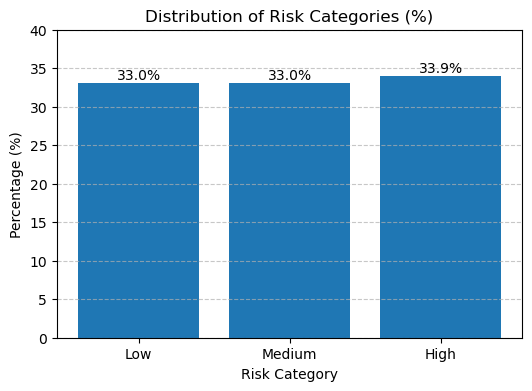

In [97]:
import matplotlib.pyplot as plt

# Calculate percentage distribution
risk_percent = cleaned["Risk_Category"].value_counts(normalize=True) * 100

# Sort for consistent order (optional)
risk_percent = risk_percent.reindex(["Low", "Medium", "High"])

# Plot
plt.figure(figsize=(6,4))
plt.bar(risk_percent.index, risk_percent.values)

# Add percentage labels on bars
for i, v in enumerate(risk_percent.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Distribution of Risk Categories (%)")
plt.xlabel("Risk Category")
plt.ylabel("Percentage (%)")

plt.ylim(0, 40)  # optional, adjust based on your data
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Distribution of Housing Stress Score

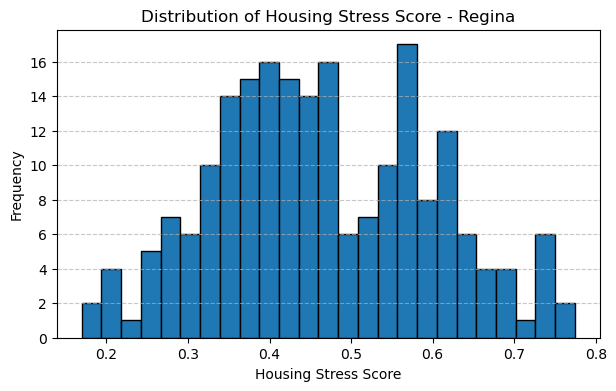

In [98]:
import matplotlib.pyplot as plt

# Regina
regina = cleaned[cleaned["City"] == "Regina"]

plt.figure(figsize=(7,4))
plt.hist(regina["Housing_Stress_Score"], bins=25, edgecolor="black")
plt.title("Distribution of Housing Stress Score - Regina")
plt.xlabel("Housing Stress Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



### 1. Regina – Distribution of Housing Stress Score

#### What the graph shows

- Most stress scores are concentrated between 0.35 and 0.60.

- The highest frequency occurs around 0.40–0.50, indicating moderate housing stress for many zones and years.

- Very few observations fall below 0.25, meaning extremely low housing stress is uncommon.

- Some observations extend up to 0.70–0.78, indicating periods or zones with higher affordability pressure.

#### Interpretation

Overall, Regina shows moderate housing affordability pressure across most zones, with only a few cases experiencing very high stress.


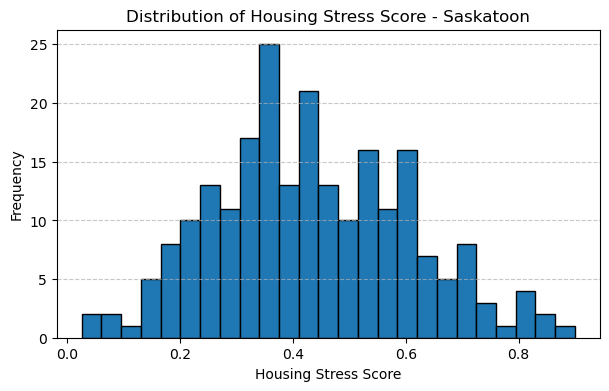

In [99]:
# Saskatoon
saskatoon = cleaned[cleaned["City"] == "Saskatoon"]

plt.figure(figsize=(7,4))
plt.hist(saskatoon["Housing_Stress_Score"], bins=25, edgecolor="black")
plt.title("Distribution of Housing Stress Score - Saskatoon")
plt.xlabel("Housing Stress Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Saskatoon – Distribution of Housing Stress Score

#### What the graph shows

- Most values lie between 0.30 and 0.60, similar to Regina.

- However, the distribution extends further to the right, reaching around 0.90.

- This indicates more observations with higher stress scores compared to Regina.

- There are also some very low values near 0.10–0.20, showing occasional lower stress periods.

#### Interpretation

Saskatoon shows slightly wider variability in housing stress, with some zones and years experiencing higher affordability pressure than those observed in Regina.


### Simple comparison 

Both cities show moderate housing stress for most observations, but Saskatoon displays a wider spread with slightly higher maximum stress levels compared to Regina.

### Correlation Analysis between Engineered Features

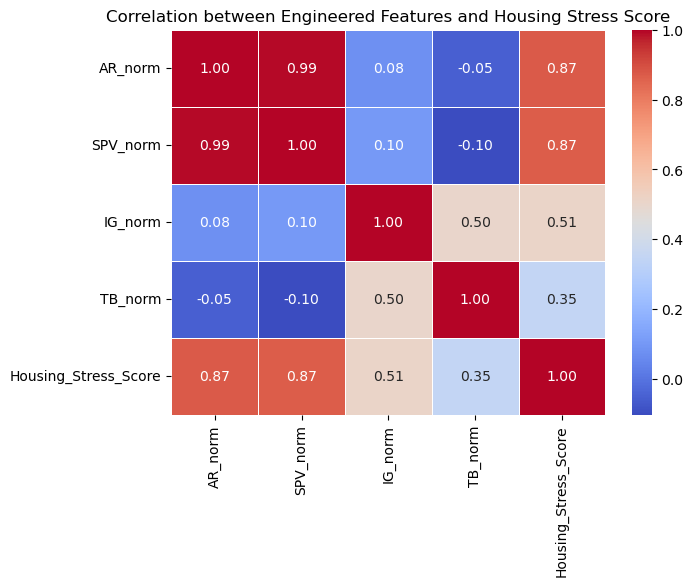

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
corr_data = cleaned[[
    "AR_norm",
    "SPV_norm",
    "IG_norm",
    "TB_norm",
    "Housing_Stress_Score"
]]

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation between Engineered Features and Housing Stress Score")

plt.show()

### 1. AR_norm vs Housing Stress Score (0.87)

This is a very strong positive correlation.

#### Meaning:

As rent burden (Affordability Ratio) increases, the housing stress score also increases.

### 2. SPV_norm vs Housing Stress Score (0.87)

This is also a very strong positive correlation.

#### Meaning:

Areas where single-person households face higher rent pressure tend to have higher housing stress.

### 3. IG_norm vs Housing Stress Score (0.51)

This is a moderate positive correlation.

#### Meaning:

When the income gap between single-person and multi-person households increases, housing stress tends to increase.

### 4. TB_norm vs Housing Stress Score (0.35)

This is a weak to moderate positive relationship.

#### Meaning:

Higher tax burden (less disposable income) slightly increases housing stress.

### 5. AR_norm vs SPV_norm (0.99)

This is extremely high correlation.

#### Meaning:

Both variables measure rent pressure relative to income, but from different perspectives.

### 6. IG_norm vs TB_norm (0.50)

Moderate correlation.

#### Meaning:

Areas with higher income inequality also tend to show larger tax burden differences.

## Final Interpretation (Best summary)

The correlation analysis shows that housing stress is primarily driven by rent-to-income pressure and single-person vulnerability, while income inequality and tax burden act as supporting socio-economic factors influencing affordability.

## Feature Contribution Analysis

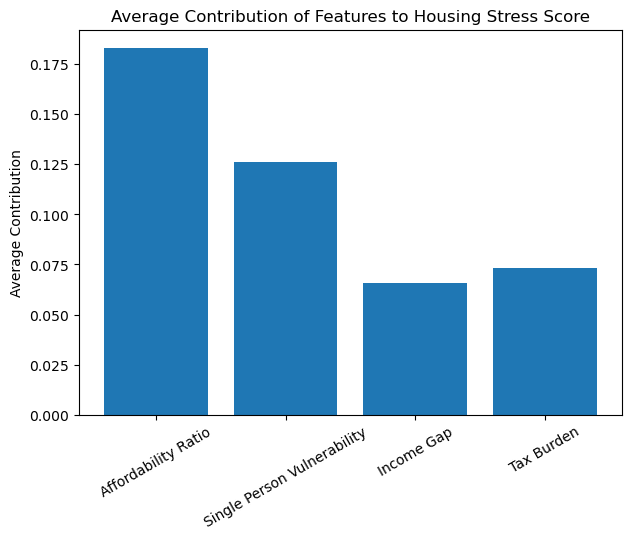

In [101]:
import matplotlib.pyplot as plt

# Compute contribution of each feature
cleaned["AR_contribution"] = 0.40 * cleaned["AR_norm"]
cleaned["SPV_contribution"] = 0.30 * cleaned["SPV_norm"]
cleaned["IG_contribution"] = 0.15 * cleaned["IG_norm"]
cleaned["TB_contribution"] = 0.15 * cleaned["TB_norm"]

# Calculate average contribution
contributions = [
    cleaned["AR_contribution"].mean(),
    cleaned["SPV_contribution"].mean(),
    cleaned["IG_contribution"].mean(),
    cleaned["TB_contribution"].mean()
]

labels = ["Affordability Ratio", "Single Person Vulnerability", "Income Gap", "Tax Burden"]

plt.figure(figsize=(7,5))
plt.bar(labels, contributions)

plt.title("Average Contribution of Features to Housing Stress Score")
plt.ylabel("Average Contribution")
plt.xticks(rotation=30)

plt.show()

### Interpretation

The chart confirms that housing stress in the dataset is primarily driven by rent burden and vulnerability of single-person households, while income inequality and tax burden play supporting roles.

In [102]:
cleaned["Bedroom_Type"].unique()

array(['1 Bedroom', '2 Bedroom', '2 Bedroom '], dtype=object)

In [103]:
cleaned["Bedroom_Type"] = cleaned["Bedroom_Type"].str.strip()
cleaned["Bedroom_Type"].unique()


array(['1 Bedroom', '2 Bedroom'], dtype=object)

## Bedroom Type Rent Distribution

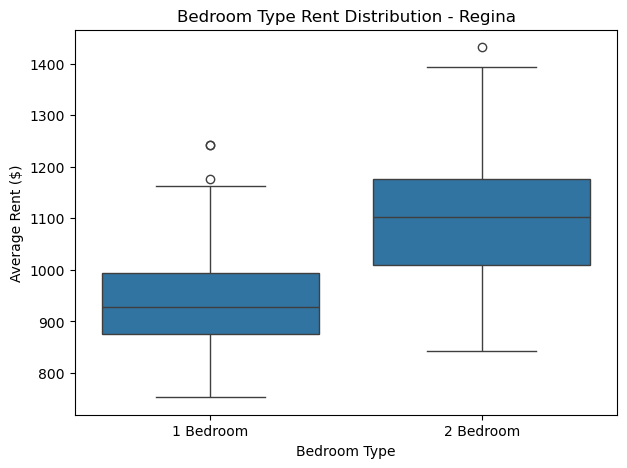

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# Regina
regina = cleaned[cleaned["City"] == "Regina"]

plt.figure(figsize=(7,5))
sns.boxplot(data=regina, x="Bedroom_Type", y="Avg_Rent")

plt.title("Bedroom Type Rent Distribution - Regina")
plt.xlabel("Bedroom Type")
plt.ylabel("Average Rent ($)")
plt.show()

This graph shows how rent varies between 1-bedroom and 2-bedroom apartments in Regina.

### 1 Bedroom Apartments

- Median rent ≈ $930

- The middle 50% of rents lie roughly between $880 and $990

- A few high-end outliers extend up to ~$1240

#### Interpretation:
1-bedroom units are generally more affordable and show relatively stable pricing across zones.

### 2 Bedroom Apartments

- Median rent ≈ $1100

- The middle 50% of rents lie roughly between $ 1000 and $ 1170

- Upper outliers reach around $1400+, indicating premium units

#### Interpretation:
2-bedroom units are consistently more expensive and show greater variability, suggesting stronger influence of location and housing quality.

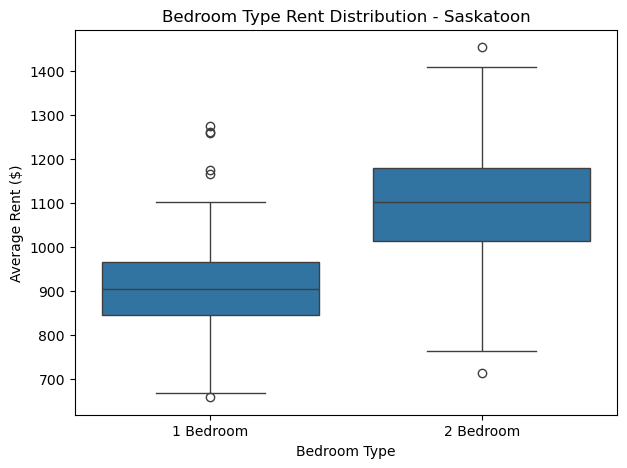

In [105]:
# Saskatoon
saskatoon = cleaned[cleaned["City"] == "Saskatoon"]

plt.figure(figsize=(7,5))
sns.boxplot(data=saskatoon, x="Bedroom_Type", y="Avg_Rent")

plt.title("Bedroom Type Rent Distribution - Saskatoon")
plt.xlabel("Bedroom Type")
plt.ylabel("Average Rent ($)")
plt.show()

This boxplot shows how rent varies between 1-bedroom and 2-bedroom apartments in Saskatoon.

### 1-Bedroom Apartments

Median rent ≈ $900

The middle 50% of rents lie roughly between $850 and $960

A few high-end outliers extend up to ~$1280

#### Intepretation:
1-bedroom units are the most affordable option and show relatively stable pricing, though a few zones or periods experience higher rents.

### 2-Bedroom Apartments

Median rent ≈ $1100

The middle 50% of rents lie roughly between $1000 and $1180

Upper outliers reach around $1400+, with a few lower-end values also observed

#### Intepretation:
2-bedroom units are consistently more expensive and exhibit greater variability, indicating stronger influence of location, unit quality, and market conditions.


### Vacancy Rate Trend Over Years

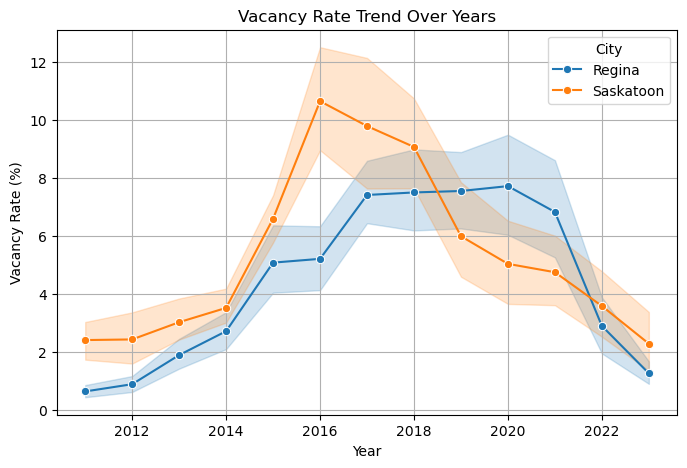

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.lineplot(data=cleaned, x="Year", y="Vacancy_Rate", hue="City", marker="o")

plt.title("Vacancy Rate Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Vacancy Rate (%)")

plt.grid(True)
plt.show()

This line chart shows how vacancy rates changed over time (2011–2023) in Regina and Saskatoon, helping understand rental market tightness.

### Regina

- Vacancy rates increased steadily from about 0.7% in 2011 to around 7–8% during 2017–2020.

- After 2020, vacancy rates declined sharply, reaching around 1–3% by 2022–2023.

#### Interpretation:
The recent decline indicates a tightening rental market, meaning fewer available apartments and potentially higher rent pressure.

### Saskatoon

- Vacancy rates rose quickly from about 2–3% in 2011 to a peak of around 10–11% in 2016.

- After 2016, vacancy rates gradually decreased, falling to around 2–4% by 2022–2023.

#### Interpretation:
The earlier high vacancy rates indicate a more relaxed rental market, but the later decline suggests increasing demand and tighter housing supply.

### Comparison Insight

- Saskatoon experienced higher vacancy rates during the mid-2010s, indicating more available rental units during that period.

- In recent years, both cities show declining vacancy rates, suggesting increasing rental market pressure.

In [107]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,...,Tax_Burden,AR_norm,SPV_norm,IG_norm,TB_norm,Housing_Stress_Score,AR_contribution,SPV_contribution,IG_contribution,TB_contribution
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,...,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,12212.618938,3.796767,...,10451.572748,0.457681,0.420782,0.438768,0.489389,0.448531,0.183072,0.126235,0.065815,0.073408
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,1784.710586,2.245425,...,590.745633,0.195555,0.187847,0.320504,0.261971,0.155486,0.078222,0.056354,0.048076,0.039296
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,7896.000000,1.000000,...,9348.000000,0.000000,0.000000,0.000000,0.000000,0.025811,0.000000,0.000000,0.000000,0.000000
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,10836.000000,2.000000,...,10016.000000,0.292042,0.268678,0.188464,0.296231,0.341712,0.116817,0.080603,0.028270,0.044435
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,11952.000000,4.000000,...,10458.000000,0.442159,0.397757,0.293369,0.492239,0.435142,0.176864,0.119327,0.044005,0.073836
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,13416.000000,6.000000,...,10873.000000,0.598729,0.549569,0.824798,0.676275,0.565007,0.239492,0.164871,0.123720,0.101441
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,17448.000000,8.000000,...,11603.000000,1.000000,1.000000,1.000000,1.000000,0.899694,0.400000,0.300000,0.150000,0.150000


In [108]:
import pandas as pd
import plotly.express as px

# Load data
#cleaned = pd.read_excel("Rental_Income_Merged_06-03-2026.xlsx")

# Clean column
cleaned["Bedroom_Type"] = cleaned["Bedroom_Type"].str.strip()

# =========================
# 1️⃣ REGINA INTERACTIVE GRAPH
# =========================
regina = cleaned[cleaned["City"] == "Regina"]

regina_trend = regina.groupby(["Year", "Bedroom_Type"])["Avg_Rent"].mean().reset_index()

fig1 = px.line(
    regina_trend,
    x="Year",
    y="Avg_Rent",
    color="Bedroom_Type",
    markers=True,
    title="Average Rent Trend Over Years - Regina",
    hover_data={
        "Year": True,
        "Avg_Rent": True,
        "Bedroom_Type": True
    }
)

fig1.show()

In [109]:
# =========================
# 2️⃣ SASKATOON INTERACTIVE GRAPH
# =========================
saskatoon = cleaned[cleaned["City"] == "Saskatoon"]

saskatoon_trend = saskatoon.groupby(["Year", "Bedroom_Type"])["Avg_Rent"].mean().reset_index()

fig2 = px.line(
    saskatoon_trend,
    x="Year",
    y="Avg_Rent",
    color="Bedroom_Type",
    markers=True,
    title="Average Rent Trend Over Years - Saskatoon",
    hover_data={
        "Year": True,
        "Avg_Rent": True,
        "Bedroom_Type": True
    }
)

fig2.show()

In [110]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Annual_Rent,Zone_Num,...,Tax_Burden,AR_norm,SPV_norm,IG_norm,TB_norm,Housing_Stress_Score,AR_contribution,SPV_contribution,IG_contribution,TB_contribution
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,...,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,12212.618938,3.796767,...,10451.572748,0.457681,0.420782,0.438768,0.489389,0.448531,0.183072,0.126235,0.065815,0.073408
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,1784.710586,2.245425,...,590.745633,0.195555,0.187847,0.320504,0.261971,0.155486,0.078222,0.056354,0.048076,0.039296
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,7896.000000,1.000000,...,9348.000000,0.000000,0.000000,0.000000,0.000000,0.025811,0.000000,0.000000,0.000000,0.000000
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,10836.000000,2.000000,...,10016.000000,0.292042,0.268678,0.188464,0.296231,0.341712,0.116817,0.080603,0.028270,0.044435
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,11952.000000,4.000000,...,10458.000000,0.442159,0.397757,0.293369,0.492239,0.435142,0.176864,0.119327,0.044005,0.073836
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,13416.000000,6.000000,...,10873.000000,0.598729,0.549569,0.824798,0.676275,0.565007,0.239492,0.164871,0.123720,0.101441
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,17448.000000,8.000000,...,11603.000000,1.000000,1.000000,1.000000,1.000000,0.899694,0.400000,0.300000,0.150000,0.150000


In [111]:
cleaned.columns

Index(['City', 'Zone', 'Year', 'Bedroom_Type', 'Vacancy_Rate', 'Avg_Rent',
       'No_Of_Apts', 'Median_Before_Tax_Income_Of_Households',
       'Median_After_Tax_Income_Of_Households',
       'Median_After_Tax_Income_1Person',
       'Median_After_Tax_Income_2Plus_Person', 'Annual_Rent', 'Zone_Num',
       'Affordability_Ratio', 'SPV', 'Income_Gap', 'Tax_Burden', 'AR_norm',
       'SPV_norm', 'IG_norm', 'TB_norm', 'Housing_Stress_Score',
       'Risk_Category', 'AR_contribution', 'SPV_contribution',
       'IG_contribution', 'TB_contribution'],
      dtype='object')

In [112]:
print(cleaned['Zone'].unique())

['Zone 1 - Central' 'Zone 2 - South: Lakeview/Albert Park'
 'Zone 3 - South: Wascana University' 'Zone 4 - East' 'Zone 5 - West'
 'Zone 6 - Northeast' 'Zone 7 - Northwest' 'Regina City (Zones 1-7)'
 'Zone 2 - South' 'Zone 3 - Southeast' 'Zone 4 - Northeast'
 'Zone 5 - North' 'Zone 6 - Southwest' 'Zone 7 - West'
 'Saskatoon City (Zones 1-7)' 'Zone 8 - Outlying Areas']


# Renamed Column names for proper Readability

In [113]:
cleaned = cleaned.rename(columns={
    'Affordability_Ratio': 'Rent_to_Income_Ratio',
    'SPV': 'Single_Person_Vulnerability',
    'Income_Gap': 'Income_Inequality',
    'Tax_Burden': 'Tax_Impact'
})

# Dropped unnecessary columns

In [114]:
# Columns to DROP (unnecessary for dashboards)
cols_to_drop = [
    # Normalized (model-only)
    'AR_norm', 'SPV_norm', 'IG_norm', 'TB_norm',

    # Contribution (already inside stress score)
    'AR_contribution', 'SPV_contribution',
    'IG_contribution', 'TB_contribution',

    # Redundant engineered
    'Annual_Rent'
]

# Drop safely
cleaned = cleaned.drop(columns=cols_to_drop, errors='ignore')

# Check final columns
cleaned.columns

Index(['City', 'Zone', 'Year', 'Bedroom_Type', 'Vacancy_Rate', 'Avg_Rent',
       'No_Of_Apts', 'Median_Before_Tax_Income_Of_Households',
       'Median_After_Tax_Income_Of_Households',
       'Median_After_Tax_Income_1Person',
       'Median_After_Tax_Income_2Plus_Person', 'Zone_Num',
       'Rent_to_Income_Ratio', 'Single_Person_Vulnerability',
       'Income_Inequality', 'Tax_Impact', 'Housing_Stress_Score',
       'Risk_Category'],
      dtype='object')

In [115]:
# Keep original zone text (important for interpretation)
cleaned["Zone"] = cleaned["Zone"].astype(str).str.strip()

In [116]:
print(cleaned["Zone"].unique())

['Zone 1 - Central' 'Zone 2 - South: Lakeview/Albert Park'
 'Zone 3 - South: Wascana University' 'Zone 4 - East' 'Zone 5 - West'
 'Zone 6 - Northeast' 'Zone 7 - Northwest' 'Regina City (Zones 1-7)'
 'Zone 2 - South' 'Zone 3 - Southeast' 'Zone 4 - Northeast'
 'Zone 5 - North' 'Zone 6 - Southwest' 'Zone 7 - West'
 'Saskatoon City (Zones 1-7)' 'Zone 8 - Outlying Areas']


In [117]:
cleaned[cleaned["Zone"].str.extract(r"(\d+)")[0].isnull()]["Zone"].unique()

array([], dtype=object)

In [118]:
# Extract numeric zone (works for all formats)
cleaned["Zone_Num"] = (
    cleaned["Zone"]
    .str.extract(r"(\d+)")
    .astype(float)
)

# Drop invalid rows (if any)
cleaned = cleaned.dropna(subset=["Zone_Num"])

# Convert to integer
cleaned["Zone_Num"] = cleaned["Zone_Num"].astype(int)

In [119]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Zone_Num,Rent_to_Income_Ratio,Single_Person_Vulnerability,Income_Inequality,Tax_Impact,Housing_Stress_Score
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,3.796767,0.176240,0.325476,49151.570439,10451.572748,0.448531
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,2.245425,0.022932,0.043366,2972.678713,590.745633,0.155486
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,1.000000,0.122571,0.228333,45082.000000,9348.000000,0.025811
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,2.000000,0.156817,0.290361,46830.000000,10016.000000,0.341712
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,4.000000,0.174420,0.320160,47803.000000,10458.000000,0.435142
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,6.000000,0.192780,0.355207,52732.000000,10873.000000,0.565007
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,8.000000,0.239835,0.459194,54357.000000,11603.000000,0.899694


In [120]:
agg = (
    cleaned
    .groupby(["City", "Year", "Zone", "Zone_Num", "Bedroom_Type"], as_index=False)
    .agg(
        Avg_Rent=("Avg_Rent", "mean"),
        Vacancy_Rate=("Vacancy_Rate", "mean"),
        Housing_Stress_Score=("Housing_Stress_Score", "mean")
    )
)

In [121]:
def classify_risk(score):
    if score < 0.37:
        return "Low"
    elif score <= 0.52:
        return "Medium"
    else:
        return "High"

agg["Risk_Category"] = agg["Housing_Stress_Score"].apply(classify_risk)

In [122]:
cleaned["Risk_Category"].value_counts()

Risk_Category
High      147
Low       143
Medium    143
Name: count, dtype: int64

In [123]:
agg = agg.sort_values(
    ["City", "Bedroom_Type", "Year", "Zone_Num"]
).reset_index(drop=True)

In [124]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Zone_Num,Rent_to_Income_Ratio,Single_Person_Vulnerability,Income_Inequality,Tax_Impact,Housing_Stress_Score
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,3.796767,0.176240,0.325476,49151.570439,10451.572748,0.448531
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,2.245425,0.022932,0.043366,2972.678713,590.745633,0.155486
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,1.000000,0.122571,0.228333,45082.000000,9348.000000,0.025811
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,2.000000,0.156817,0.290361,46830.000000,10016.000000,0.341712
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,4.000000,0.174420,0.320160,47803.000000,10458.000000,0.435142
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,6.000000,0.192780,0.355207,52732.000000,10873.000000,0.565007
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,8.000000,0.239835,0.459194,54357.000000,11603.000000,0.899694


In [125]:
import plotly.express as px

hover_template = (
    "Zone: %{customdata[0]}<br>"
    "Bedroom Type: %{customdata[1]}<br>"
    "Vacancy Rate: %{customdata[2]:.2f}%<br>"
    "Avg Rent: $%{customdata[3]:.0f}<br>"
    "Stress Score: %{y:.2f}<br>"
    "Risk Level: %{customdata[4]}<extra></extra>"
)

def make_chart(city, bedroom_type):
    df = agg[
        (agg["City"] == city) &
        (agg["Bedroom_Type"] == bedroom_type)
    ]

    fig = px.bar(
        df,
        x="Year",
        y="Housing_Stress_Score",
        color="Zone",   # ✅ IMPORTANT FIX
        barmode="group",
        custom_data=[
            "Zone",
            "Bedroom_Type",
            "Vacancy_Rate",
            "Avg_Rent",
            "Risk_Category"
        ],
        title=f"Housing Stress (Zone-wise) - {city} ({bedroom_type})"
    )

    fig.update_traces(hovertemplate=hover_template)

    fig.update_layout(
        xaxis_title="Year",
        yaxis_title="Housing Stress Score",
        legend_title="Zone",
        bargap=0.15
    )

    return fig

In [126]:
# Regina - 1 Bedroom
fig1 = make_chart("Regina", "1 Bedroom")
fig1.show()

# Regina - 2 Bedroom
fig2 = make_chart("Regina", "2 Bedroom")
fig2.show()

# Saskatoon - 1 Bedroom
fig3 = make_chart("Saskatoon", "1 Bedroom")
fig3.show()

# Saskatoon - 2 Bedroom
fig4 = make_chart("Saskatoon", "2 Bedroom")
fig4.show()

## 1. Regina – 1 Bedroom 
- Housing stress shows a steady upward trend from 2011 to ~2016–2017, indicating worsening affordability.
- A slight stabilization or mild dip is visible around 2017–2019.
- From 2020 onwards, stress increases again, reaching higher levels by 2022–2023.
- Zone 7 (Northwest) consistently shows the highest stress levels, while Zone 5 (West) and Zone 6 (Northeast) remain relatively lower.

## 2. Regina – 2 Bedroom 
- Stress levels are consistently higher than 1-bedroom units across all years.
- A strong rise from 2011 to 2015–2016, followed by moderate fluctuations.
- From 2019 onwards, stress increases steadily again, reaching peak levels by 2023.
- Zone 7 (Northwest) and Zone 4 (East) show highest stress, while Zone 5 (West) and Zone 6 (Northeast) remain comparatively lower.

## Comparison: Regina (1 Bedroom vs 2 Bedroom)
- 2-bedroom units consistently show higher stress than 1-bedroom units
- Both follow a similar trend pattern:
  - Increase (2011–2016)
  - Slight stabilization (2017–2019)
  - Rise again (post-2020)
- Gap between 1B and 2B remains consistent, indicating structural affordability difference

## Conclusion:
In Regina, larger units are consistently less affordable, but overall growth pattern is stable and gradual.

## Saskatoon – 1 Bedroom 
- Gradual increase from 2011 to ~2015, followed by fluctuations around 2016–2019.
- A sharp rise after 2020, indicating increasing affordability pressure in recent years.
- Zone 8 (Outlying Areas) shows a sudden spike post-2020, becoming one of the highest stress zones.
- Other zones show moderate and steady increases, with some variability.

## Saskatoon – 2 Bedroom 
- Clear upward trend across all years, stronger than 1-bedroom.
- Stress levels rise steadily from 2011 to 2015, then remain high with fluctuations.
- From 2020 onwards, sharp increase, reaching the highest levels among all graphs by 2023.
- Zone 8 (Outlying Areas) and Zone 1 (Central) show very high stress, while Zone 6 (Southwest) remains relatively lower.

## Comparison 2: Saskatoon (1 Bedroom vs 2 Bedroom)
- 2-bedroom units show significantly higher stress than 1-bedroom
- Post-2020, 2-bedroom stress increases much more sharply
- Zone 8 impact is stronger in 2-bedroom, indicating outer areas becoming expensive
- 1-bedroom shows moderate growth, while 2-bedroom shows aggressive increase

## Conclusion:
In Saskatoon, the affordability gap between 1B and 2B is wider and growing, especially in recent years.

## Overall Comparison (Regina vs Saskatoon)

### 📊 Trend Comparison
- Both cities show:
  - Increase → slight stabilization → sharp rise (post-2020)
- Saskatoon shows more volatility and sharper increases
  
### 📊 Stress Levels
- Saskatoon (especially 2-bedroom) reaches higher stress levels than Regina
- Regina shows more controlled and stable growth

### 📊 Zone Behavior
- Regina:
  - Stress more evenly distributed across zones
- Saskatoon:
  - Certain zones (especially Zone 8) show sudden spikes
    
### 📊 Affordability Insight
- Regina → Moderate but steadily worsening affordability
- Saskatoon → Rapidly worsening affordability, especially post-2020

In [127]:
cleaned['Zone'].unique()

array(['Zone 1 - Central', 'Zone 2 - South: Lakeview/Albert Park',
       'Zone 3 - South: Wascana University', 'Zone 4 - East',
       'Zone 5 - West', 'Zone 6 - Northeast', 'Zone 7 - Northwest',
       'Regina City (Zones 1-7)', 'Zone 2 - South', 'Zone 3 - Southeast',
       'Zone 4 - Northeast', 'Zone 5 - North', 'Zone 6 - Southwest',
       'Zone 7 - West', 'Saskatoon City (Zones 1-7)',
       'Zone 8 - Outlying Areas'], dtype=object)

In [128]:
cleaned.columns

Index(['City', 'Zone', 'Year', 'Bedroom_Type', 'Vacancy_Rate', 'Avg_Rent',
       'No_Of_Apts', 'Median_Before_Tax_Income_Of_Households',
       'Median_After_Tax_Income_Of_Households',
       'Median_After_Tax_Income_1Person',
       'Median_After_Tax_Income_2Plus_Person', 'Zone_Num',
       'Rent_to_Income_Ratio', 'Single_Person_Vulnerability',
       'Income_Inequality', 'Tax_Impact', 'Housing_Stress_Score',
       'Risk_Category'],
      dtype='object')

In [129]:
cleaned.describe()

,Year,Vacancy_Rate,Avg_Rent,No_Of_Apts,Median_Before_Tax_Income_Of_Households,Median_After_Tax_Income_Of_Households,Median_After_Tax_Income_1Person,Median_After_Tax_Income_2Plus_Person,Zone_Num,Rent_to_Income_Ratio,Single_Person_Vulnerability,Income_Inequality,Tax_Impact,Housing_Stress_Score
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,2017.004619,4.895612,1017.718245,1464.849885,79714.295612,69262.722864,37521.443418,86673.013857,3.796767,0.176240,0.325476,49151.570439,10451.572748,0.448531
std,3.741036,3.775997,148.725882,1823.085717,4453.783998,4074.775304,2272.199305,5128.006894,2.245425,0.022932,0.043366,2972.678713,590.745633,0.155486
min,2011.000000,0.000000,658.000000,19.000000,72468.000000,63120.000000,33883.000000,78965.000000,1.000000,0.122571,0.228333,45082.000000,9348.000000,0.025811
25%,2014.000000,1.900000,903.000000,453.000000,76457.000000,66074.000000,35666.000000,82696.000000,2.000000,0.156817,0.290361,46830.000000,10016.000000,0.341712
50%,2017.000000,4.300000,996.000000,829.000000,78112.000000,68036.000000,36917.000000,85115.000000,4.000000,0.174420,0.320160,47803.000000,10458.000000,0.435142
75%,2020.000000,6.800000,1118.000000,1426.000000,83530.000000,73072.000000,38665.000000,91217.000000,6.000000,0.192780,0.355207,52732.000000,10873.000000,0.565007
max,2023.000000,19.400000,1454.000000,9319.000000,88389.000000,77005.000000,42277.000000,96634.000000,8.000000,0.239835,0.459194,54357.000000,11603.000000,0.899694


In [130]:
cleaned = cleaned.sort_values(
    ["City", "Zone_Num", "Bedroom_Type", "Year"]
)

In [131]:
cleaned.to_excel("final_dataset_without_CMA.xlsx", index=False)